# Exam Score Prediction

### Import libraries

In [209]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,OneHotEncoder,OrdinalEncoder,LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score


In [210]:
df=pd.read_csv('StudentPerformanceFactors.csv')

In [211]:
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [212]:
df.tail()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
6602,25,69,High,Medium,No,7,76,Medium,Yes,1,High,Medium,Public,Positive,2,No,High School,Near,Female,68
6603,23,76,High,Medium,No,8,81,Medium,Yes,3,Low,High,Public,Positive,2,No,High School,Near,Female,69
6604,20,90,Medium,Low,Yes,6,65,Low,Yes,3,Low,Medium,Public,Negative,2,No,Postgraduate,Near,Female,68
6605,10,86,High,High,Yes,6,91,High,Yes,2,Low,Medium,Private,Positive,3,No,High School,Far,Female,68
6606,15,67,Medium,Low,Yes,9,94,Medium,Yes,0,Medium,Medium,Public,Positive,4,No,Postgraduate,Near,Male,64


In [213]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Hours_Studied               6607 non-null   int64
 1   Attendance                  6607 non-null   int64
 2   Parental_Involvement        6607 non-null   str  
 3   Access_to_Resources         6607 non-null   str  
 4   Extracurricular_Activities  6607 non-null   str  
 5   Sleep_Hours                 6607 non-null   int64
 6   Previous_Scores             6607 non-null   int64
 7   Motivation_Level            6607 non-null   str  
 8   Internet_Access             6607 non-null   str  
 9   Tutoring_Sessions           6607 non-null   int64
 10  Family_Income               6607 non-null   str  
 11  Teacher_Quality             6529 non-null   str  
 12  School_Type                 6607 non-null   str  
 13  Peer_Influence              6607 non-null   str  
 14  Physical_Activity  

In [214]:
df.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


In [215]:
df.columns.to_list()

['Hours_Studied',
 'Attendance',
 'Parental_Involvement',
 'Access_to_Resources',
 'Extracurricular_Activities',
 'Sleep_Hours',
 'Previous_Scores',
 'Motivation_Level',
 'Internet_Access',
 'Tutoring_Sessions',
 'Family_Income',
 'Teacher_Quality',
 'School_Type',
 'Peer_Influence',
 'Physical_Activity',
 'Learning_Disabilities',
 'Parental_Education_Level',
 'Distance_from_Home',
 'Gender',
 'Exam_Score']

In [216]:
print(df.isna().sum())

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64


In [217]:
#fill missing values
avg=df['Distance_from_Home'].mode()
df['Distance_from_Home']=df['Distance_from_Home'].fillna(avg) 

avg1=df['Teacher_Quality'].mode()
df['Teacher_Quality']=df['Teacher_Quality'].fillna(avg1) 

avg2=df['Parental_Education_Level'].mode()
df['Parental_Education_Level']=df['Parental_Education_Level'].fillna(avg2) 


In [218]:
print(df.isna().sum())

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64


In [219]:
df.duplicated().sum()

np.int64(0)

In [220]:
# univariate analysis
num_cols=df.select_dtypes(include=['int64','Float64']).columns

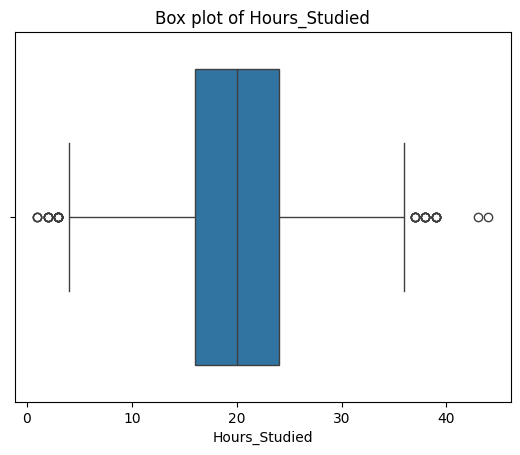

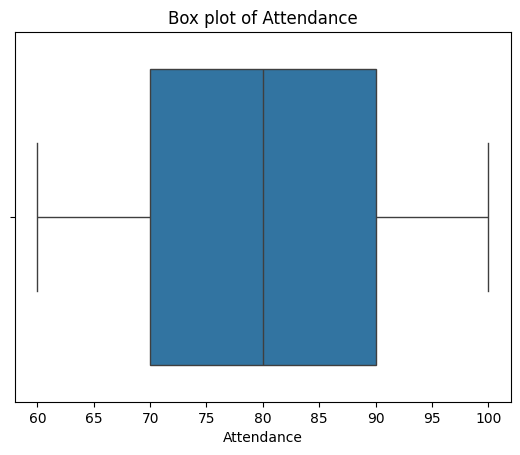

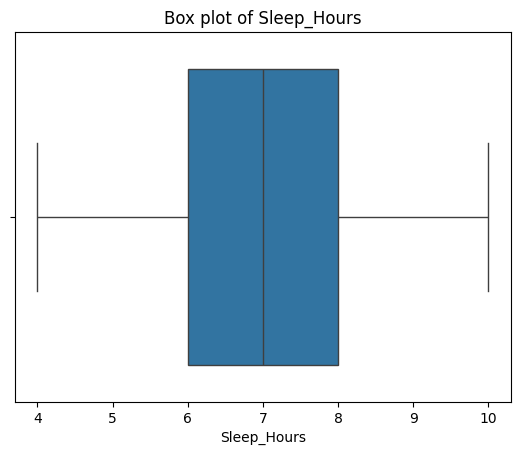

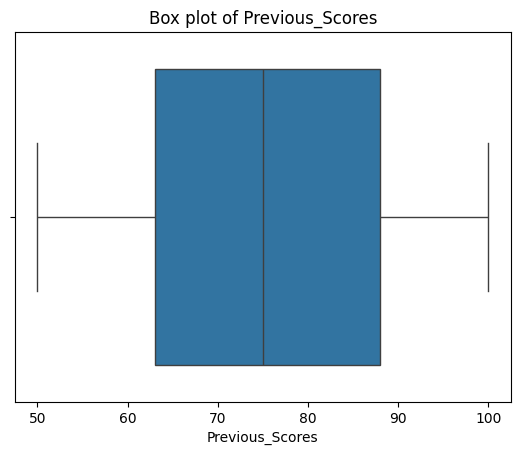

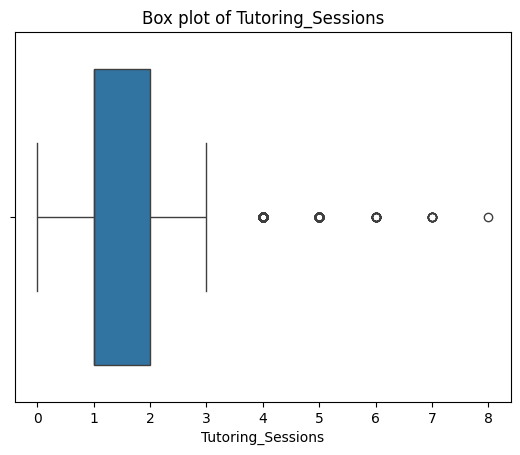

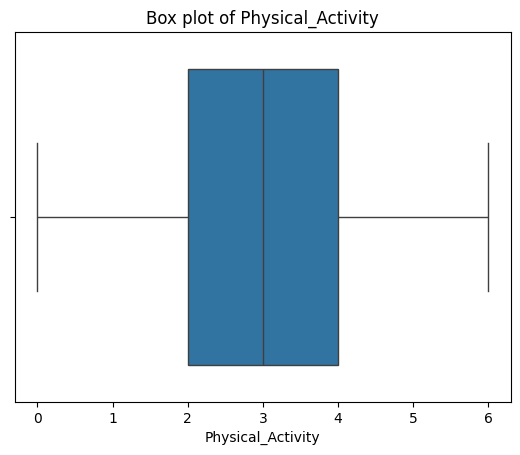

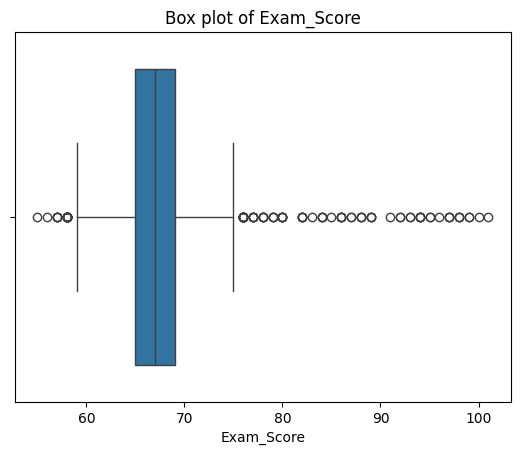

In [221]:
for col in num_cols:
    plt.Figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(f'Box plot of {col}')
    plt.show()

In [222]:
cate_cols=df.select_dtypes(include=['str']).columns

C:\Users\kiran\AppData\Local\Temp\ipykernel_21700\3623055899.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col],palette='colorblind')  #deep,muted,bright,dark,rainbow,pastel,colorblind


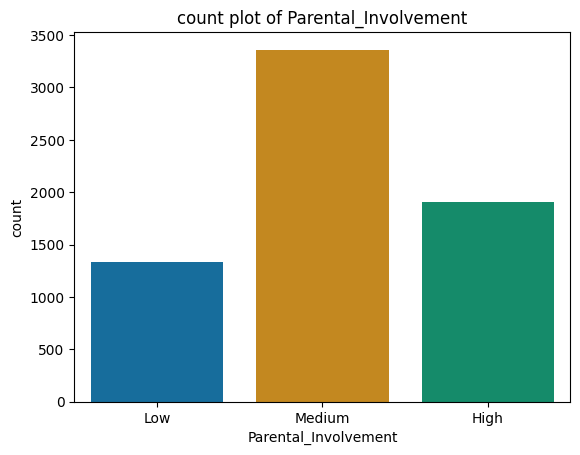

C:\Users\kiran\AppData\Local\Temp\ipykernel_21700\3623055899.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col],palette='colorblind')  #deep,muted,bright,dark,rainbow,pastel,colorblind


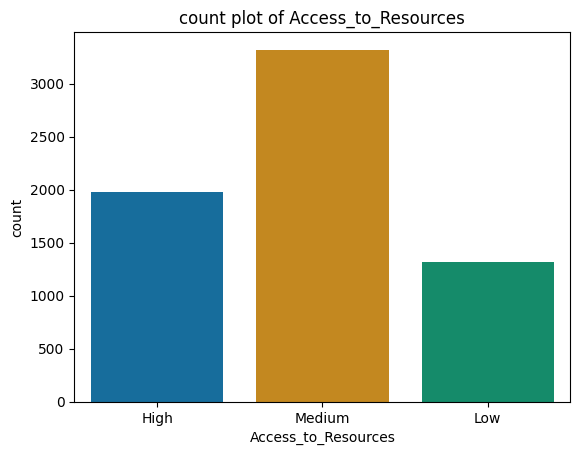

C:\Users\kiran\AppData\Local\Temp\ipykernel_21700\3623055899.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col],palette='colorblind')  #deep,muted,bright,dark,rainbow,pastel,colorblind


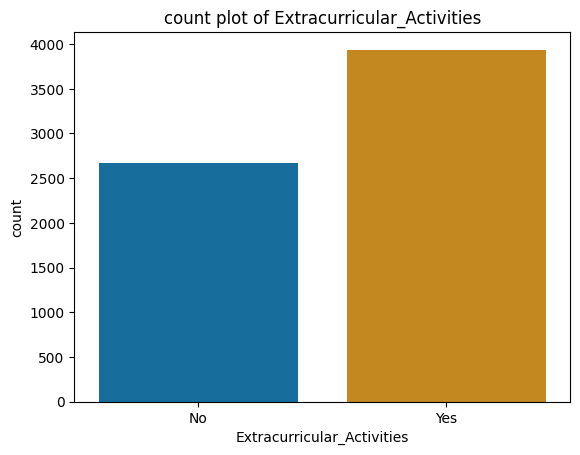

C:\Users\kiran\AppData\Local\Temp\ipykernel_21700\3623055899.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col],palette='colorblind')  #deep,muted,bright,dark,rainbow,pastel,colorblind


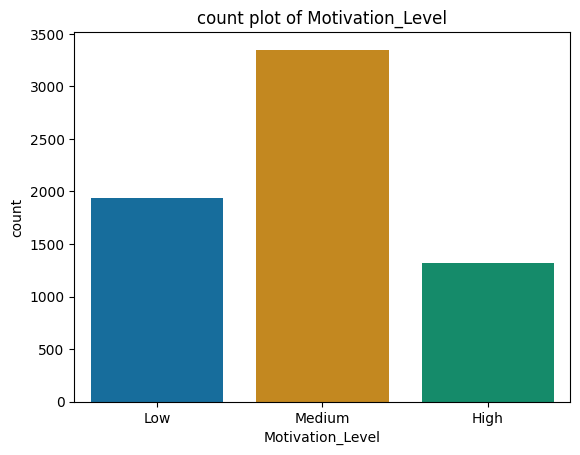

C:\Users\kiran\AppData\Local\Temp\ipykernel_21700\3623055899.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col],palette='colorblind')  #deep,muted,bright,dark,rainbow,pastel,colorblind


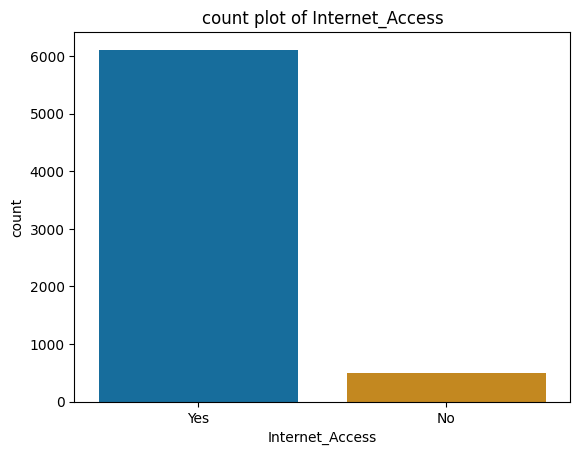

C:\Users\kiran\AppData\Local\Temp\ipykernel_21700\3623055899.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col],palette='colorblind')  #deep,muted,bright,dark,rainbow,pastel,colorblind


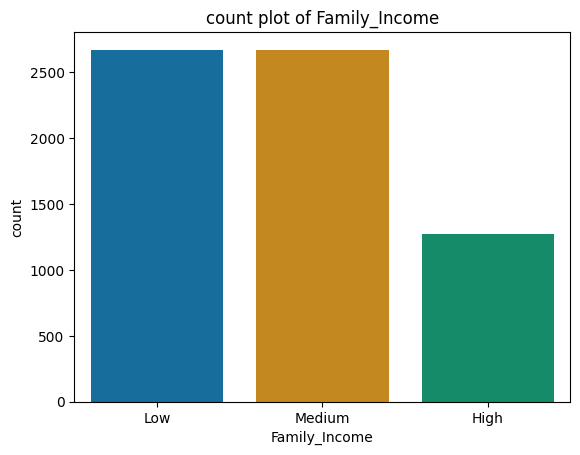

C:\Users\kiran\AppData\Local\Temp\ipykernel_21700\3623055899.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col],palette='colorblind')  #deep,muted,bright,dark,rainbow,pastel,colorblind


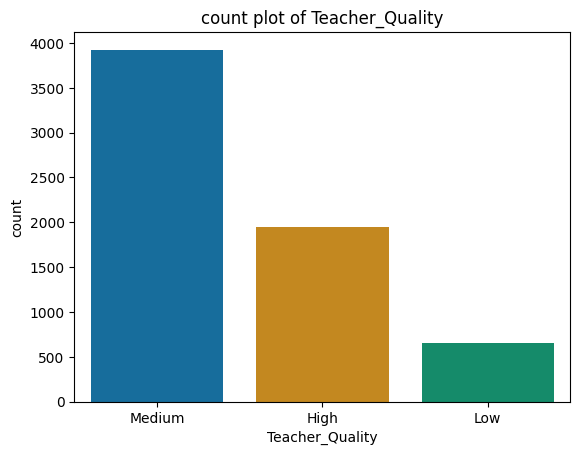

C:\Users\kiran\AppData\Local\Temp\ipykernel_21700\3623055899.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col],palette='colorblind')  #deep,muted,bright,dark,rainbow,pastel,colorblind


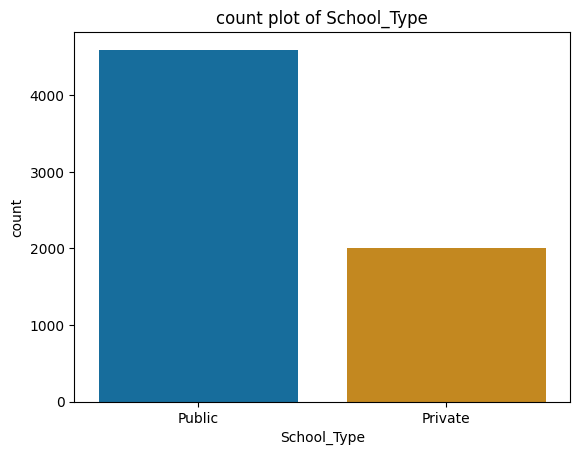

C:\Users\kiran\AppData\Local\Temp\ipykernel_21700\3623055899.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col],palette='colorblind')  #deep,muted,bright,dark,rainbow,pastel,colorblind


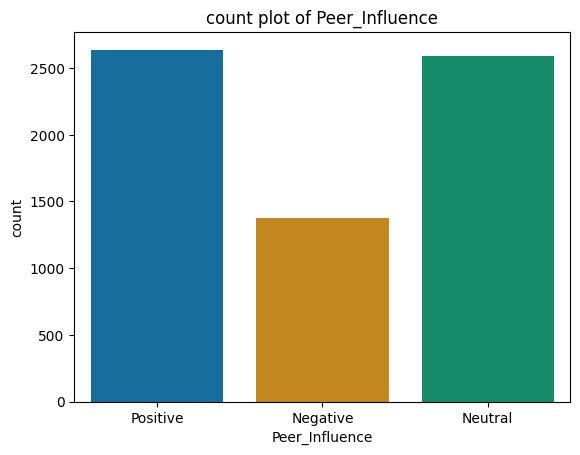

C:\Users\kiran\AppData\Local\Temp\ipykernel_21700\3623055899.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col],palette='colorblind')  #deep,muted,bright,dark,rainbow,pastel,colorblind


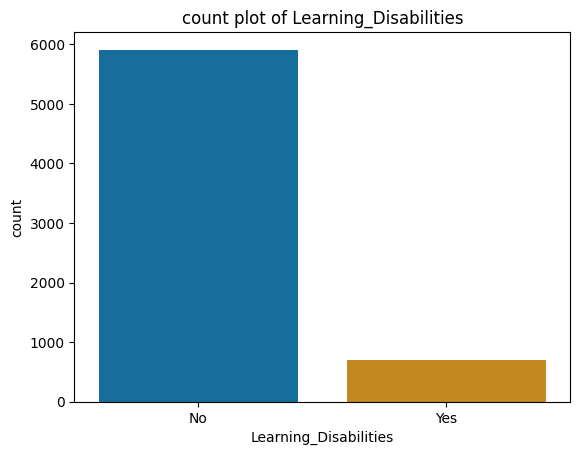

C:\Users\kiran\AppData\Local\Temp\ipykernel_21700\3623055899.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col],palette='colorblind')  #deep,muted,bright,dark,rainbow,pastel,colorblind


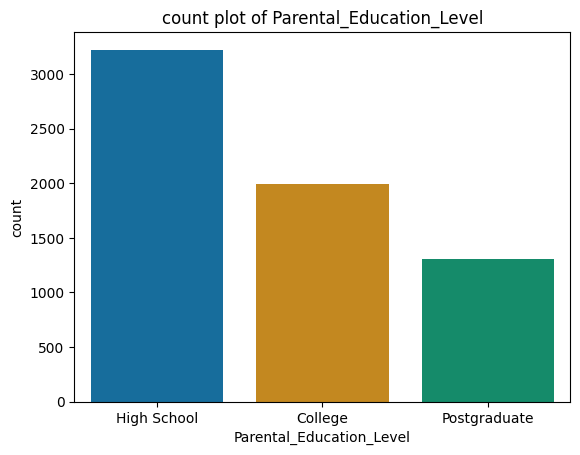

C:\Users\kiran\AppData\Local\Temp\ipykernel_21700\3623055899.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col],palette='colorblind')  #deep,muted,bright,dark,rainbow,pastel,colorblind


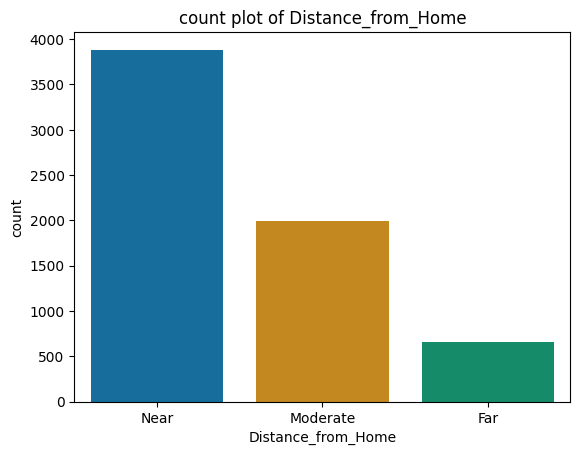

C:\Users\kiran\AppData\Local\Temp\ipykernel_21700\3623055899.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col],palette='colorblind')  #deep,muted,bright,dark,rainbow,pastel,colorblind


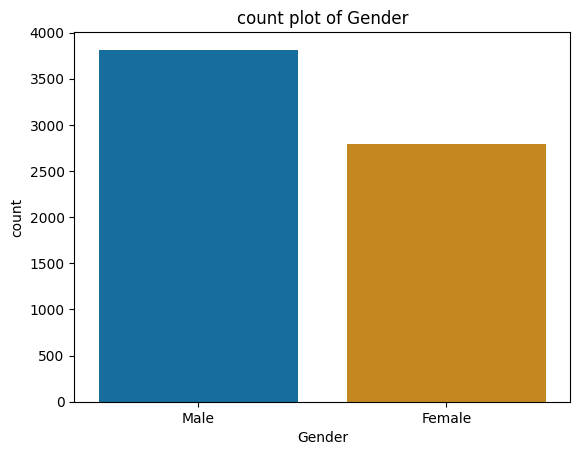

In [223]:
for col in cate_cols:
    plt.Figure(figsize=(6,3))
    sns.countplot(x=df[col],palette='colorblind')  #deep,muted,bright,dark,rainbow,pastel,colorblind
    plt.title(f'count plot of {col}')
    plt.show()

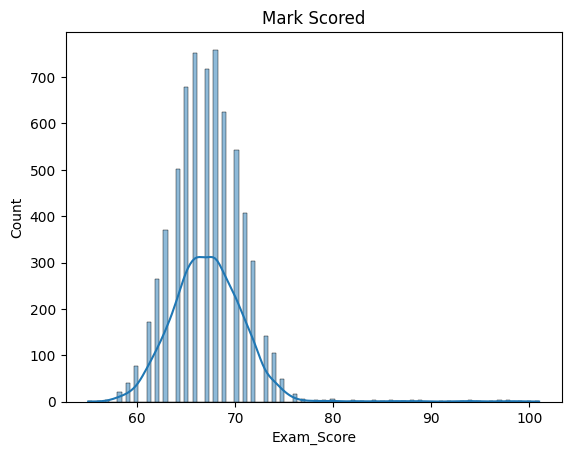

In [224]:
sns.histplot(df['Exam_Score'],kde=True)
plt.title('Mark Scored')
plt.show()

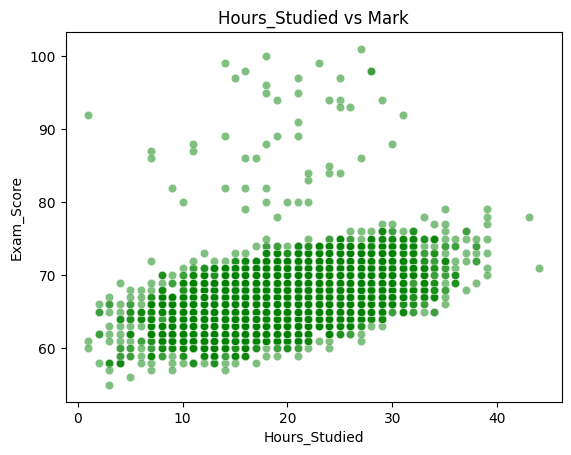

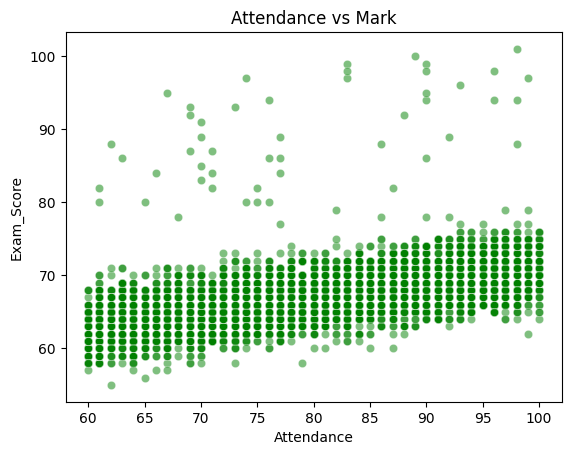

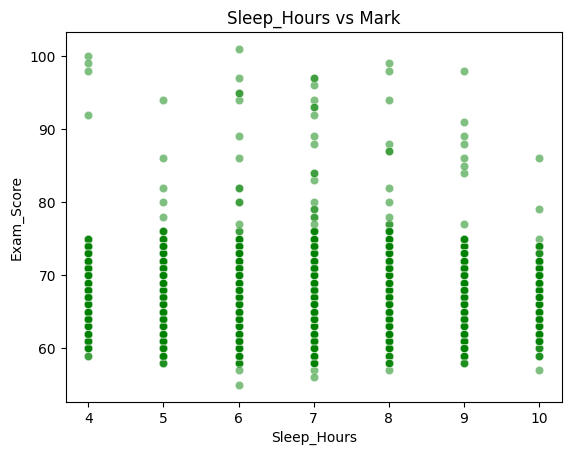

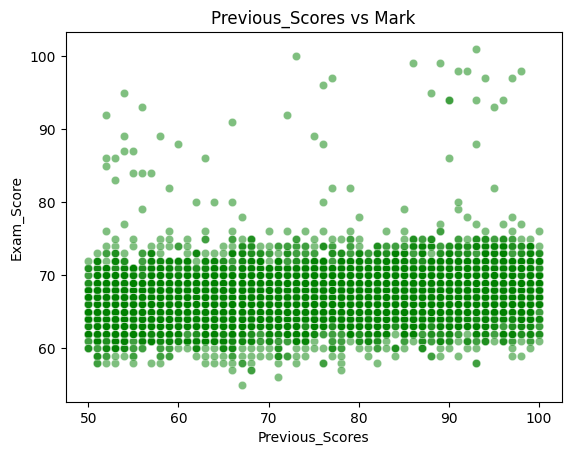

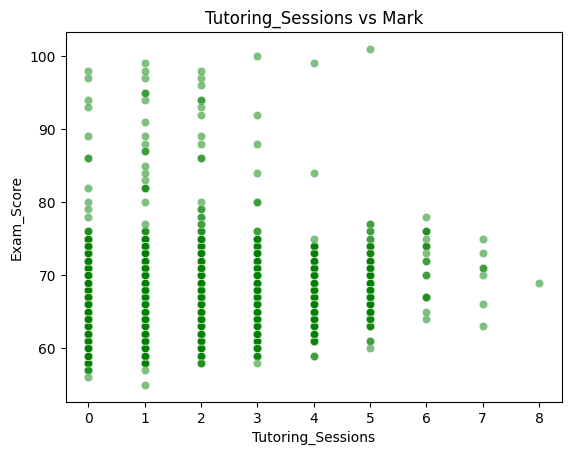

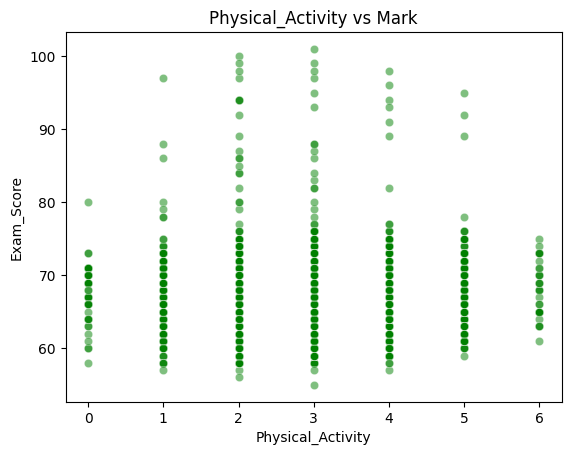

In [225]:
# numerical vs target
for col in num_cols:
    if col !='Exam_Score':
        plt.Figure(figsize=(6,3))
        sns.scatterplot(x=df[col],y=df['Exam_Score'],color='green',alpha=0.5)
        plt.title(f'{col} vs Mark')
        plt.show()

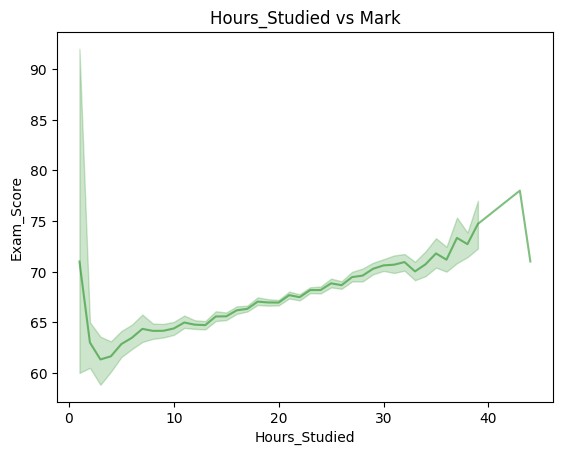

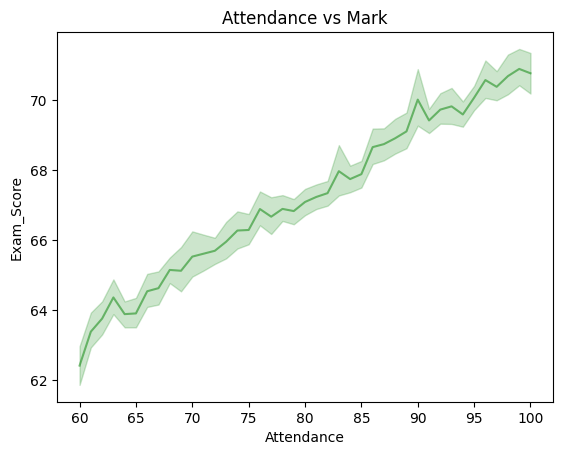

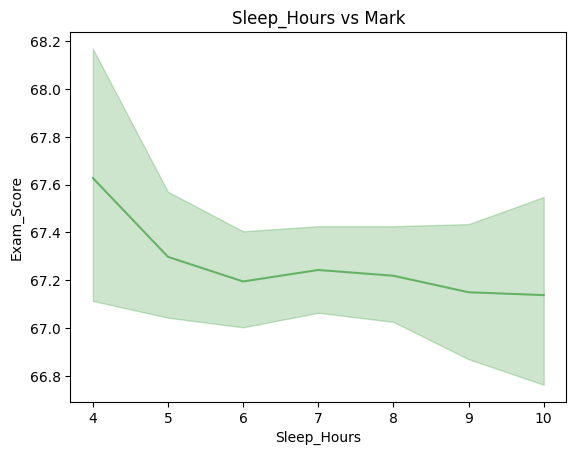

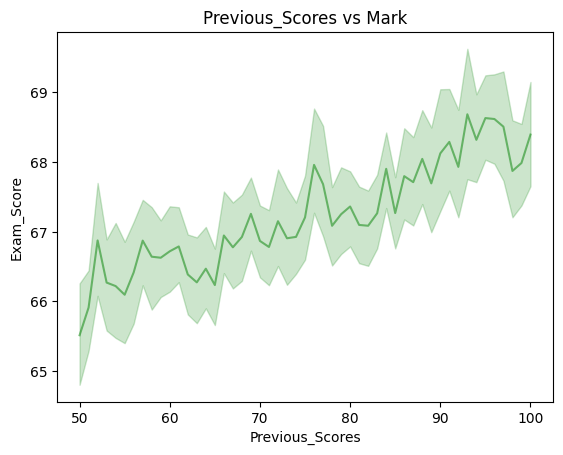

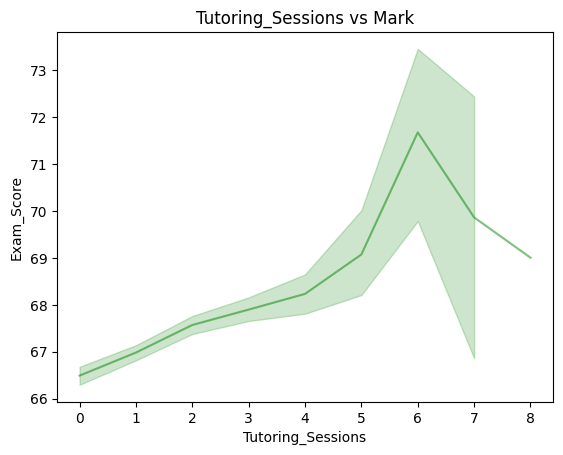

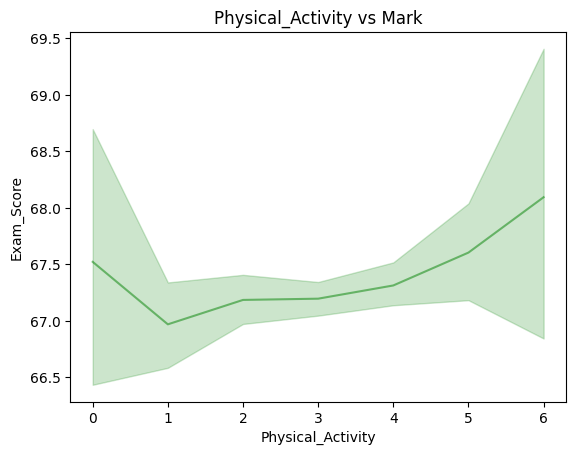

In [226]:
for col in num_cols:
    if col !='Exam_Score':
        plt.Figure(figsize=(6,3))
        sns.lineplot(x=df[col],y=df['Exam_Score'],color='green',alpha=0.5)
        plt.title(f'{col} vs Mark')
        plt.show()

C:\Users\kiran\AppData\Local\Temp\ipykernel_21700\2867098847.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df[col],y=df['Exam_Score'],palette='rainbow')


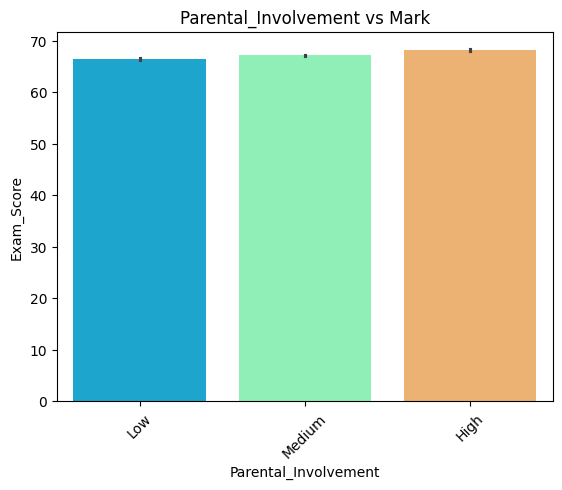

C:\Users\kiran\AppData\Local\Temp\ipykernel_21700\2867098847.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df[col],y=df['Exam_Score'],palette='rainbow')


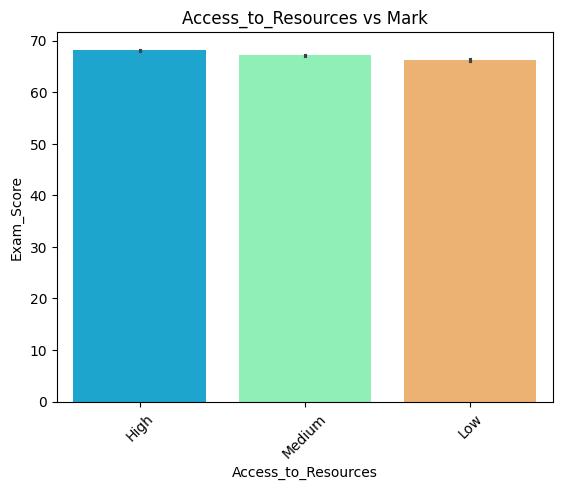

C:\Users\kiran\AppData\Local\Temp\ipykernel_21700\2867098847.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df[col],y=df['Exam_Score'],palette='rainbow')


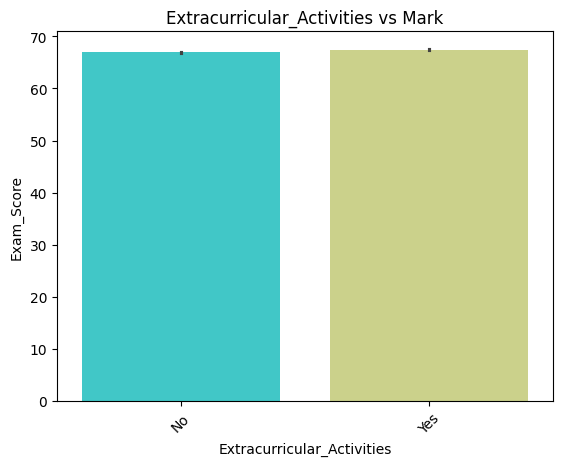

C:\Users\kiran\AppData\Local\Temp\ipykernel_21700\2867098847.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df[col],y=df['Exam_Score'],palette='rainbow')


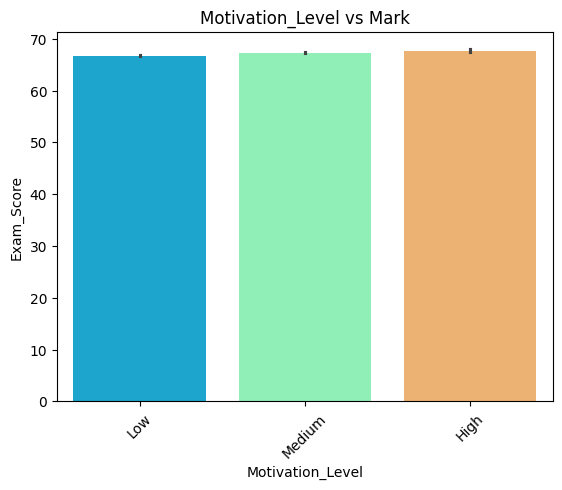

C:\Users\kiran\AppData\Local\Temp\ipykernel_21700\2867098847.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df[col],y=df['Exam_Score'],palette='rainbow')


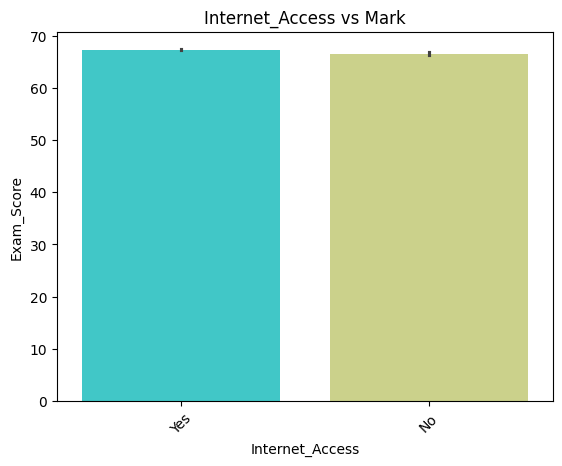

C:\Users\kiran\AppData\Local\Temp\ipykernel_21700\2867098847.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df[col],y=df['Exam_Score'],palette='rainbow')


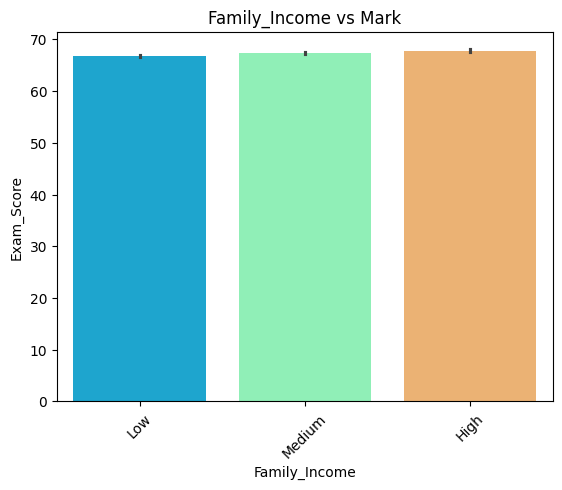

C:\Users\kiran\AppData\Local\Temp\ipykernel_21700\2867098847.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df[col],y=df['Exam_Score'],palette='rainbow')


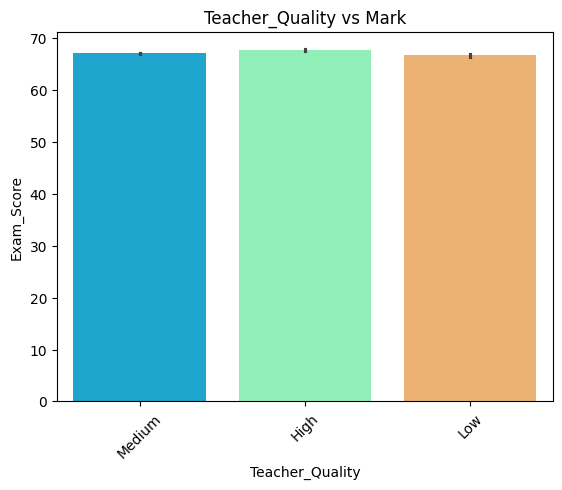

C:\Users\kiran\AppData\Local\Temp\ipykernel_21700\2867098847.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df[col],y=df['Exam_Score'],palette='rainbow')


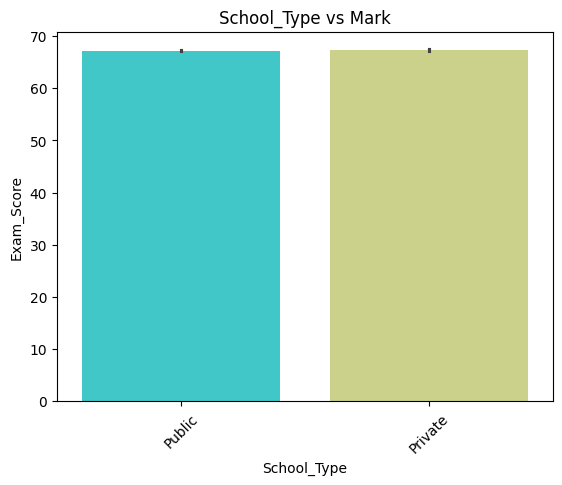

C:\Users\kiran\AppData\Local\Temp\ipykernel_21700\2867098847.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df[col],y=df['Exam_Score'],palette='rainbow')


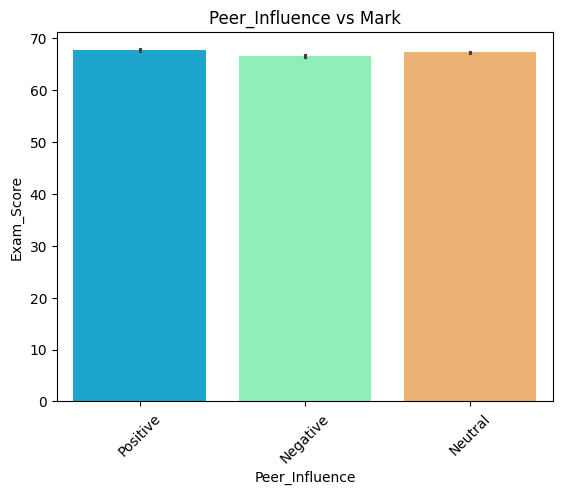

C:\Users\kiran\AppData\Local\Temp\ipykernel_21700\2867098847.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df[col],y=df['Exam_Score'],palette='rainbow')


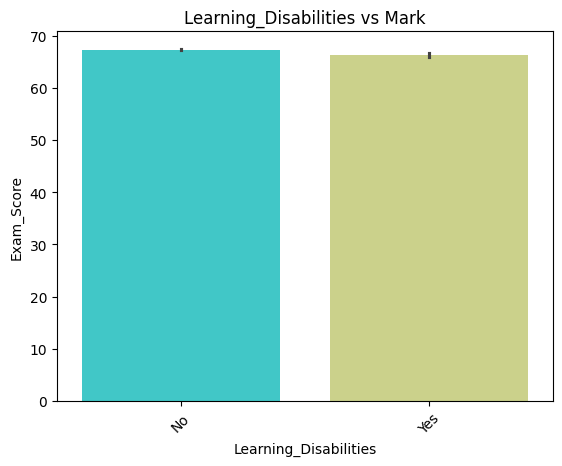

C:\Users\kiran\AppData\Local\Temp\ipykernel_21700\2867098847.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df[col],y=df['Exam_Score'],palette='rainbow')


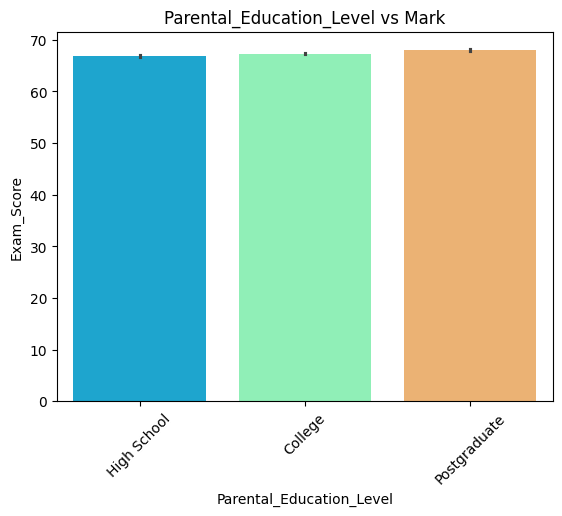

C:\Users\kiran\AppData\Local\Temp\ipykernel_21700\2867098847.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df[col],y=df['Exam_Score'],palette='rainbow')


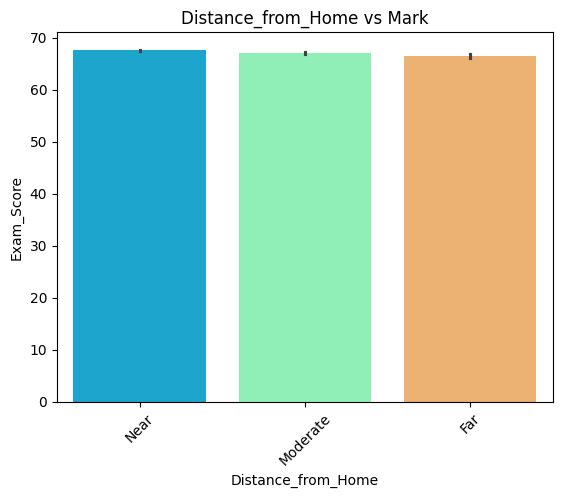

C:\Users\kiran\AppData\Local\Temp\ipykernel_21700\2867098847.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df[col],y=df['Exam_Score'],palette='rainbow')


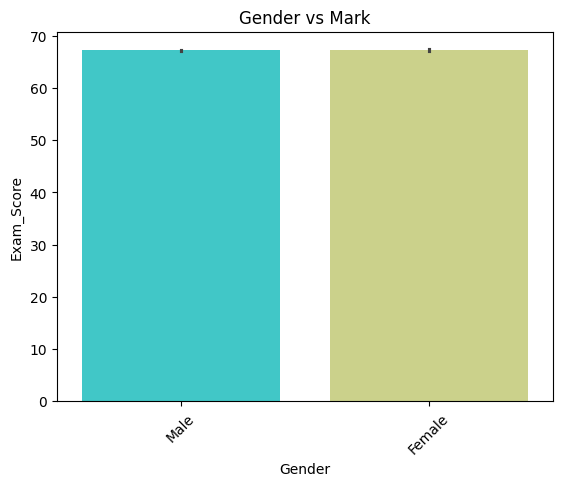

In [227]:
for col in cate_cols:
        plt.Figure(figsize=(6,3))
        sns.barplot(x=df[col],y=df['Exam_Score'],palette='rainbow')
        plt.title(f'{col} vs Mark')
        plt.xticks(rotation=45)
        plt.show()

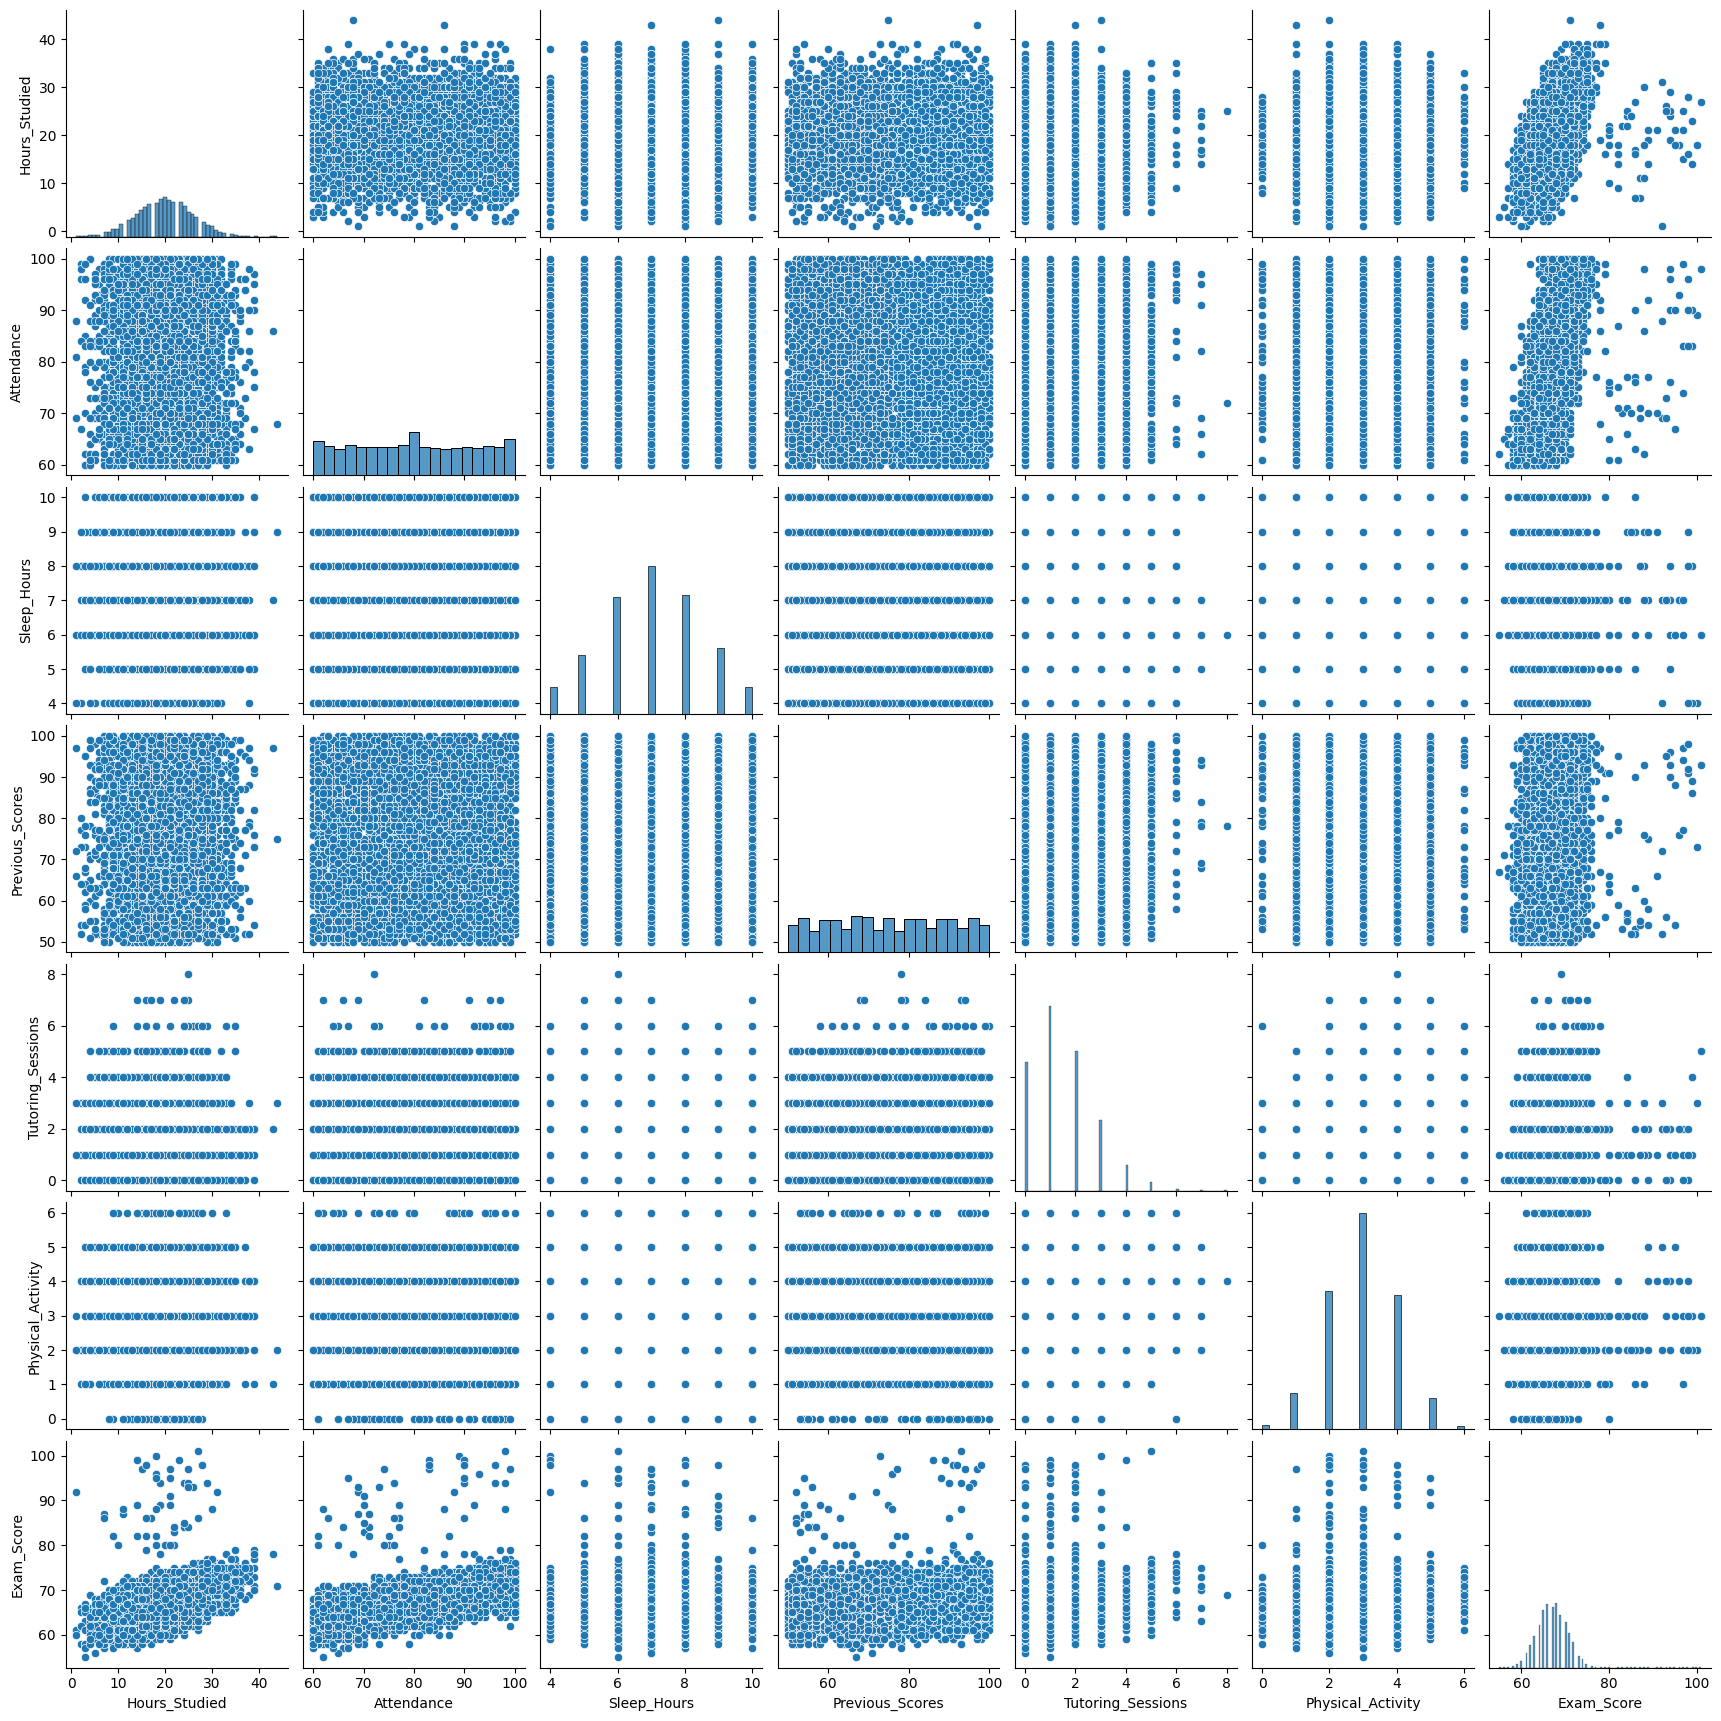

In [228]:
sns.pairplot(df[num_cols])
plt.show()

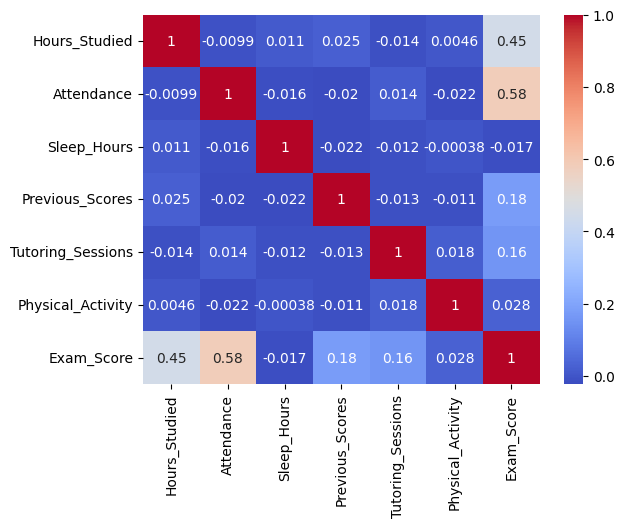

In [229]:
# Correlation heatmap

plt.Figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='coolwarm')
plt.show()

# Feature Selecton

In [230]:
#Define target
target='Exam_Score'

# SPLIT FEATURES AND TARGET
x=df.drop(columns=[target])
y=df[target]

#seperate column types
num_cols=x.select_dtypes(include=['int64','float64']).columnscat_cols=x.select_dtypes(include=['str']).columns
print("numberical:",num_cols)
print("categorical:",cate_cols)

numberical: Index(['Parental_Involvement', 'Access_to_Resources',
       'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access',
       'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence',
       'Learning_Disabilities', 'Parental_Education_Level',
       'Distance_from_Home', 'Gender'],
      dtype='str')
categorical: Index(['Parental_Involvement', 'Access_to_Resources',
       'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access',
       'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence',
       'Learning_Disabilities', 'Parental_Education_Level',
       'Distance_from_Home', 'Gender'],
      dtype='str')


C:\Users\kiran\AppData\Local\Temp\ipykernel_21700\3924202319.py:9: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  num_cols=x.select_dtypes(include=['int64','float64']).columnscat_cols=x.select_dtypes(include=['str']).columns


# Train Test Split

In [231]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [232]:
cate_cols

Index(['Parental_Involvement', 'Access_to_Resources',
       'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access',
       'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence',
       'Learning_Disabilities', 'Parental_Education_Level',
       'Distance_from_Home', 'Gender'],
      dtype='str')

In [233]:
num_cols=df.select_dtypes(include=['int64','float']).columns

In [234]:
num_col=num_cols.drop(['Exam_Score'])

# Scalling

In [235]:
scaler=StandardScaler()

x_train_num=scaler.fit_transform(x_train[num_col])
x_test_num=scaler.transform(x_test[num_col])

x_train_num=pd.DataFrame(x_train_num,columns=num_col,index=x_train.index)
x_test_num=pd.DataFrame(x_test_num,columns=num_col,index=x_test.index)
print(x_test_num)
print(x_train_num)

      Hours_Studied  Attendance  Sleep_Hours  Previous_Scores  \
743        0.005494   -0.770407    -0.016740         0.828791   
5551       0.339232   -0.770407    -0.016740         1.592406   
3442       0.172363    0.965995    -0.702575        -1.531472   
6571      -1.329460    0.965995     0.669094         0.412274   
4204       0.172363   -1.464968     0.669094         1.384147   
...             ...         ...          ...              ...   
4709       0.005494   -0.162667     2.040764         0.689952   
3664       1.173579    0.879175    -0.016740         1.175889   
5231       0.506102   -0.683587    -0.702575        -0.976116   
1773       0.172363   -0.336307    -0.702575        -1.739730   
5782       0.506102    0.618714    -1.388410         1.453567   

      Tutoring_Sessions  Physical_Activity  
743           -0.405017           1.964909  
5551           0.405784          -0.936882  
3442          -0.405017           0.030381  
6571          -1.215819           0.997

# Ordinal Encoding

In [236]:
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [237]:
df.columns

Index(['Hours_Studied', 'Attendance', 'Parental_Involvement',
       'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours',
       'Previous_Scores', 'Motivation_Level', 'Internet_Access',
       'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type',
       'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities',
       'Parental_Education_Level', 'Distance_from_Home', 'Gender',
       'Exam_Score'],
      dtype='str')

In [238]:
df['Distance_from_Home'].value_counts()

Distance_from_Home
Near        3884
Moderate    1998
Far          658
Name: count, dtype: int64

In [239]:
df['Distance_from_Home'].value_counts()

Distance_from_Home
Near        3884
Moderate    1998
Far          658
Name: count, dtype: int64

# Ordinal Encoding

In [240]:
ordinal_cols=['Parental_Involvement','Access_to_Resources','Motivation_Level','Family_Income','Teacher_Quality','Parental_Education_Level','Distance_from_Home']

ordinal_order=[['Low','Medium','High'],
               ['Low','Medium','High'],
               ['Low','Medium','High'],
               ['Low','Medium','High'],
                ['Low','Medium','High'],
                ['High School','College','Postgraduate'],
                ['Near','Moderate','Far']]
ordinal_encorder=OrdinalEncoder(categories=ordinal_order,handle_unknown='use_encoded_value',unknown_value=-1)

x_train_ord=ordinal_encorder.fit_transform(x_train[ordinal_cols])
x_test_ord=ordinal_encorder.transform(x_test[ordinal_cols])


x_train_ord = pd.DataFrame(x_train_ord, columns=ordinal_cols, index=x_train.index)
x_test_ord = pd.DataFrame(x_test_ord, columns=ordinal_cols, index=x_test.index)

# One Hot Encoding

In [241]:
nominal_cols=[
'School_Type',
'Peer_Influence',
'Gender'
]
ohe=OneHotEncoder(handle_unknown='ignore',
sparse_output=False)
x_train_nom=ohe.fit_transform(x_train[nominal_cols])
x_test_nom=ohe.transform(x_test[nominal_cols])
nom_cols_encoded=ohe.get_feature_names_out(nominal_cols)

x_train_nom=pd.DataFrame(x_train_nom,columns=nom_cols_encoded,index=x_train.index)
x_test_nom=pd.DataFrame(x_test_nom,columns=nom_cols_encoded,index=x_test.index)

# Label Encoding

In [242]:
label_cols = ['Extracurricular_Activities', 'Internet_Access', 'Learning_Disabilities']
label_encoders = {}
for col in label_cols:
    le = LabelEncoder()
    x_train[col] = le.fit_transform(x_train[col])
    x_test[col] = le.transform(x_test[col])
    
    label_encoders[col] = le

In [243]:
x_train_final=pd.concat([x_train_num,x_train_ord,x_train_nom],axis=1)
x_test_final=pd.concat([x_test_num,x_test_ord,x_test_nom],axis=1)

In [244]:
x_train_final.select_dtypes(include=['object']).columns

Index([], dtype='str')

In [245]:
model=LinearRegression()
model.fit(x_train_final,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [246]:
y_pred=model.predict(x_test_final)

In [247]:
print("R2Score:",r2_score(y_test,y_pred))

R2Score: 0.7586195686219956


In [248]:
y_pred=model.predict(x_test_final)
print(y_pred[:10])

[64.78599757 64.90384856 71.10096646 63.98404612 66.02999645 66.19186839
 72.13103827 65.9810973  69.55546307 69.62667766]


# NEW dataframe

In [269]:
new_data=pd.DataFrame({
'Hours_Studied':[25],
'Attendance':[12],
'Parental_Involvement':['Low'],
'Access_to_Resources':['High'],
'Extracurricular_Activities':['Yes'],
'Sleep_Hours':[7],
'Previous_Scores':['70'],
'Motivation_Level':['High'],
'Internet_Access':['Yes'],
'Tutoring_Sessions':[3],
'Family_Income':['Medium'],
'Teacher_Quality':['High'],
'School_Type':['Public'],
'Peer_Influence':['Positive'],
'Physical_Activity':[3],
'Learning_Disabilities':['No'],
'Parental_Education_Level':['College'],
'Distance_from_Home':['Near'],
'Gender':['Male']
})


In [257]:
ordinal_encorder=OrdinalEncoder(categories=ordinal_order,handle_unknown='use_encoded_value',unknown_value=-1)

In [272]:
new_ord=ordinal_encorder.transform(new_data[['Parental_Involvement','Access_to_Resources','Motivation_Level','Family_Income','Teacher_Quality','Parental_Education_Level','Distance_from_Home']])
new_ord=pd.DataFrame(new_ord,columns=['Parental_Involvement','Access_to_Resources','Motivation_Level','Family_Income','Teacher_Quality','Parental_Education_Level','Distance_from_Home'])

In [274]:
new_num=scaler.transform(new_data[num_col])
new_num=pd.DataFrame(new_num,columns=num_col)

In [276]:
new_nom=ohe.transform(new_data[nominal_cols])
new_nom=pd.DataFrame(new_nom,columns=nom_cols_encoded)

In [278]:
new_final=pd.concat([new_num,new_ord,new_nom],axis=1)

In [280]:
prediction=model.predict(new_final)
print("Predicted Exam Score:",prediction[0].round(2))

Predicted Exam Score: 57.42
